In [1]:
# Question 8: Simulated Data and Model Selection

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
#Part (a) and (b): Generate simulated data
np.random.seed(42)

n = 100

# Generate predictor and noise
X = np.random.normal(size=n)
eps = np.random.normal(size=n)

# Choose coefficients
beta0 = 2
beta1 = 3
beta2 = -2
beta3 = 0.5

# Generate response
Y = beta0 + beta1 * X + beta2 * X**2 + beta3 * X**3 + eps

# Create dataframe with X, X^2, ..., X^10
data = pd.DataFrame({"Y": Y})

for i in range(1, 11):
    data[f"X{i}"] = X**i

data.head()

,Y,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,1.642598,0.496714,0.246725,0.122552,0.060873,0.030237,0.015019,7.460119e-03,3.705547e-03,1.840597e-03,9.142508e-04
1,1.125006,-0.138264,0.019117,-0.002643,0.000365,-0.000051,0.000007,-9.659851e-07,1.335613e-07,-1.846675e-08,2.553293e-09
2,2.897203,0.647689,0.419500,0.271706,0.175981,0.113981,0.073824,4.781493e-02,3.096918e-02,2.005838e-02,1.299158e-02
3,2.893998,1.523030,2.319620,3.532850,5.380637,8.194870,12.481032,1.900898e+01,2.895125e+01,4.409362e+01,6.715590e+01
4,1.020180,-0.234153,0.054828,-0.012838,0.003006,-0.000704,0.000165,-3.859250e-05,9.036565e-06,-2.115942e-06,4.954550e-07


In [3]:
#Add forward and backward selection functions
def calculate_cp(model, X_full, y):
    n = len(y)
    p = model.df_model + 1
    rss = np.sum(model.resid ** 2)

    full_model = sm.OLS(y, sm.add_constant(X_full)).fit()
    sigma2 = np.sum(full_model.resid ** 2) / full_model.df_resid

    cp = (rss / sigma2) - (n - 2 * p)
    return cp


def forward_selection(X_data, y):
    remaining = list(X_data.columns)
    selected = []
    results = []

    while remaining:
        best_cp = np.inf
        best_var = None
        best_model = None

        for var in remaining:
            predictors = selected + [var]
            model = sm.OLS(y, sm.add_constant(X_data[predictors])).fit()
            cp = calculate_cp(model, X_data, y)

            if cp < best_cp:
                best_cp = cp
                best_var = var
                best_model = model

        selected.append(best_var)
        remaining.remove(best_var)

        results.append({
            "predictors": selected.copy(),
            "Cp": best_cp,
            "model": best_model
        })

    return results


def backward_selection(X_data, y):
    selected = list(X_data.columns)
    results = []

    while len(selected) > 0:
        best_cp = np.inf
        best_vars = None
        best_model = None

        for var in selected:
            predictors = [v for v in selected if v != var]

            if len(predictors) == 0:
                model = sm.OLS(y, np.ones((len(y), 1))).fit()
            else:
                model = sm.OLS(y, sm.add_constant(X_data[predictors])).fit()

            cp = calculate_cp(model, X_data, y)

            if cp < best_cp:
                best_cp = cp
                best_vars = predictors
                best_model = model

        selected = best_vars

        results.append({
            "predictors": selected.copy(),
            "Cp": best_cp,
            "model": best_model
        })

    return results

In [4]:
#Part (c): Forward stepwise selection
X_data = data.drop(columns=["Y"])
y = data["Y"]

forward_results = forward_selection(X_data, y)

forward_table = pd.DataFrame({
    "Step": range(1, len(forward_results) + 1),
    "Predictors": [r["predictors"] for r in forward_results],
    "Cp": [r["Cp"] for r in forward_results]
})

forward_table

,Step,Predictors,Cp
0,1,[X3],418.829500
1,2,"[X3, X2]",240.689074
2,3,"[X3, X2, X1]",4.264684
3,4,"[X3, X2, X1, X10]",4.344513
4,5,"[X3, X2, X1, X10, X5]",5.304691
5,6,"[X3, X2, X1, X10, X5, X9]",7.157291
6,7,"[X3, X2, X1, X10, X5, X9, X4]",8.517300
7,8,"[X3, X2, X1, X10, X5, X9, X4, X8]",9.350456
8,9,"[X3, X2, X1, X10, X5, X9, X4, X8, X6]",9.386299
9,10,"[X3, X2, X1, X10, X5, X9, X4, X8, X6, X7]",11.000000


In [5]:
best_forward = min(forward_results, key=lambda x: x["Cp"])

print("Best Forward Predictors:", best_forward["predictors"])
print("Best Forward Cp:", best_forward["Cp"])
print(best_forward["model"].summary())

Best Forward Predictors: ['X3', 'X2', 'X1']
Best Forward Cp: 4.264684478054875
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     956.5
Date:                Wed, 06 May 2026   Prob (F-statistic):           2.39e-71
Time:                        09:01:13   Log-Likelihood:                -133.24
No. Observations:                 100   AIC:                             274.5
Df Residuals:                      96   BIC:                             284.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

In [6]:
#Part (d): Backward stepwise selection
backward_results = backward_selection(X_data, y)

backward_table = pd.DataFrame({
    "Step": range(1, len(backward_results) + 1),
    "Predictors": [r["predictors"] for r in backward_results],
    "Cp": [r["Cp"] for r in backward_results]
})

backward_table

,Step,Predictors,Cp
0,1,"[X1, X2, X3, X4, X5, X6, X7, X8, X10]",9.367475
1,2,"[X1, X2, X3, X4, X5, X6, X8, X10]",7.406659
2,3,"[X1, X2, X3, X4, X6, X8, X10]",5.736914
3,4,"[X1, X2, X3, X6, X8, X10]",5.170745
4,5,"[X1, X2, X3, X8, X10]",6.026782
5,6,"[X1, X2, X3, X10]",4.344513
6,7,"[X1, X2, X3]",4.264684
7,8,"[X1, X2]",57.122166
8,9,[X1],732.518609
9,10,[],2875.593658


In [7]:
best_backward = min(backward_results, key=lambda x: x["Cp"])

print("Best Backward Predictors:", best_backward["predictors"])
print("Best Backward Cp:", best_backward["Cp"])
print(best_backward["model"].summary())

Best Backward Predictors: ['X1', 'X2', 'X3']
Best Backward Cp: 4.264684478054875
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     956.5
Date:                Wed, 06 May 2026   Prob (F-statistic):           2.39e-71
Time:                        09:01:13   Log-Likelihood:                -133.24
No. Observations:                 100   AIC:                             274.5
Df Residuals:                      96   BIC:                             284.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [8]:
#Part (e): Lasso with cross-validation
lasso_model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=10000)
)

lasso_model.fit(X_data, y)

lasso_cv = lasso_model.named_steps["lassocv"]

print("Best alpha:", lasso_cv.alpha_)

Best alpha: 0.005714287454568303


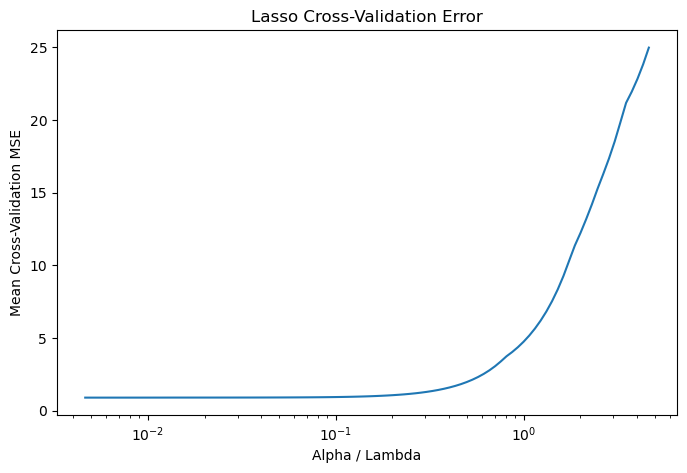

In [9]:
#Plot
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso_cv.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha / Lambda")
plt.ylabel("Mean Cross-Validation MSE")
plt.title("Lasso Cross-Validation Error")
plt.show()

In [10]:
#Coefficient
lasso_coef_table = pd.DataFrame({
    "Predictor": X_data.columns,
    "Coefficient": lasso_cv.coef_
})

lasso_coef_table

,Predictor,Coefficient
0,X1,2.735866
1,X2,-2.020518
2,X3,1.156175
3,X4,-0.000000
4,X5,-0.000000
5,X6,-0.000000
6,X7,0.000000
7,X8,-0.000000
8,X9,0.000000
9,X10,-0.225759


In [11]:
#Part (f): New model using X⁷
beta0_new = 2
beta7 = 4

Y_new = beta0_new + beta7 * X**7 + eps

data_new = pd.DataFrame({"Y": Y_new})

for i in range(1, 11):
    data_new[f"X{i}"] = X**i

X_new = data_new.drop(columns=["Y"])
y_new = data_new["Y"]

data_new.head()

,Y,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,0.614470,0.496714,0.246725,0.122552,0.060873,0.030237,0.015019,7.460119e-03,3.705547e-03,1.840597e-03,9.142508e-04
1,1.579351,-0.138264,0.019117,-0.002643,0.000365,-0.000051,0.000007,-9.659851e-07,1.335613e-07,-1.846675e-08,2.553293e-09
2,1.848545,0.647689,0.419500,0.271706,0.175981,0.113981,0.073824,4.781493e-02,3.096918e-02,2.005838e-02,1.299158e-02
3,77.233661,1.523030,2.319620,3.532850,5.380637,8.194870,12.481032,1.900898e+01,2.895125e+01,4.409362e+01,6.715590e+01
4,1.838560,-0.234153,0.054828,-0.012838,0.003006,-0.000704,0.000165,-3.859250e-05,9.036565e-06,-2.115942e-06,4.954550e-07


In [12]:
#Forward selection
forward_results_new = forward_selection(X_new, y_new)

best_forward_new = min(forward_results_new, key=lambda x: x["Cp"])

print("Best Forward Predictors:", best_forward_new["predictors"])
print("Best Forward Cp:", best_forward_new["Cp"])
print(best_forward_new["model"].summary())

Best Forward Predictors: ['X7', 'X2', 'X9']
Best Forward Cp: 1.710106828877997
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.712e+06
Date:                Wed, 06 May 2026   Prob (F-statistic):          6.72e-248
Time:                        09:01:14   Log-Likelihood:                -131.90
No. Observations:                 100   AIC:                             271.8
Df Residuals:                      96   BIC:                             282.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

In [13]:
#Lasso
lasso_model_new = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=10000)
)

lasso_model_new.fit(X_new, y_new)

lasso_cv_new = lasso_model_new.named_steps["lassocv"]

print("Best alpha:", lasso_cv_new.alpha_)

Best alpha: 0.34724673841850157


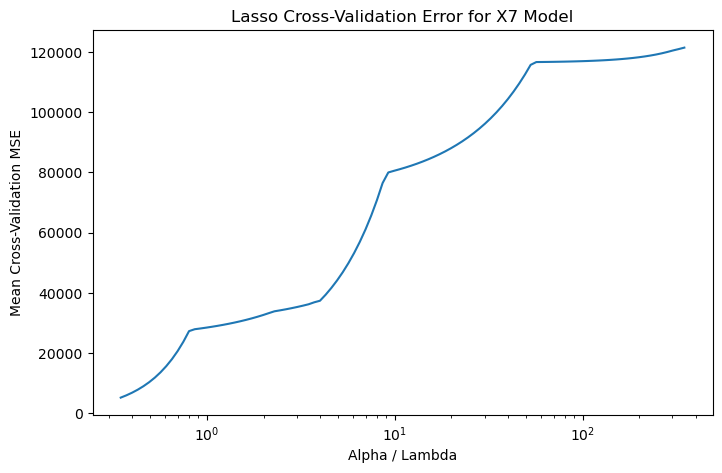

In [14]:
#Plot
mean_mse_new = np.mean(lasso_cv_new.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso_cv_new.alphas_, mean_mse_new)
plt.xscale("log")
plt.xlabel("Alpha / Lambda")
plt.ylabel("Mean Cross-Validation MSE")
plt.title("Lasso Cross-Validation Error for X7 Model")
plt.show()

In [15]:
#Coefficients
lasso_coef_table_new = pd.DataFrame({
    "Predictor": X_new.columns,
    "Coefficient": lasso_cv_new.coef_
})

lasso_coef_table_new

,Predictor,Coefficient
0,X1,-0.000000
1,X2,-0.000000
2,X3,0.000000
3,X4,-0.000000
4,X5,20.910929
5,X6,-1.041954
6,X7,284.982464
7,X8,-0.000000
8,X9,40.835966
9,X10,-0.000000
